# Predicción de erosión catódica en propulsores AF-MPD

**Modelo cinético, cierre termoiónico y evaluación de blindaje magnético HTS**

Ignacio Díaz · Gonzalo Avaria — Departamento de Física, Universidad Técnica Federico
Santa María

---

Cuaderno correspondiente al modelo vigente. Los iones de argón se integran como
partículas de prueba con el algoritmo de Boris en campos **evaluados analíticamente en la
posición de cada ion**, sin discretización espacial, y el conjunto se vectoriza con NumPy
sobre el arreglo completo de partículas.

No es un esquema PIC, MHD ni híbrido: no resuelve campos autoconsistentes, no deposita
carga sobre una malla y no incluye colisiones.

Las dos etapas preliminares del integrador —sobre malla discretizada y con campos
efectivos impuestos por regiones, ambas apoyadas en un módulo C++— fueron descartadas en
favor de este modelo. Se conservan en `notebooks/completo-sin-limpiar.ipynb` y en
`preliminar-cpp/`.


# 1 · Parámetros maestros

In [1]:
import numpy as np


#  PARÁMETROS MAESTROS  (única fuente — el resto de celdas lee de aquí)


# --- Constantes físicas (SI) ---
e      = 1.602e-19    # C        - Carga elemental
m_ion  = 6.63e-26     # kg       - Masa del ion Ar+
m_e    = 9.109e-31    # kg       - Masa del electrón
g0     = 9.80665      # m/s^2    - Gravedad estándar (Isp)

# --- Propelente: Argón ---
M_molar = 40.0        # g/mol    - Masa molar
V_ion   = 15.76       # eV       - Potencial de IONIZACIÓN (Ar -> Ar+)   [distinto de la vaina]
T_e     = 1.5         # eV       - Temperatura electrónica
T_i     = 1.5         # eV       - Temperatura iónica (inyección)

# --- Punto de operación ---
I_lab    = 222.0      # A        - Corriente nominal de diseño
B0       = 0.5        # T        - Campo magnético aplicado (garganta)
A_nozzle = 0.04       # m        - Longitud característica de la tobera

# --- Vaina del cátodo (Bohm flotante; NO confundir con V_ion) ---
V_vaina      = (T_e/2)*np.log(m_ion/(2*np.pi*m_e))  # V  ~ 7.0  (caída de vaina)
delta_vaina  = 1.0e-3 # m        - Espesor de la vaina

# --- Dominio de simulación (SI) ---
r_a_max = 5.0e-2      # m        - Radio máximo del ánodo (tope de la campana)
L_sim   = 6.5e-2      # m        - Longitud del dominio axial

# --- Entradas de diseño "Lowcost" (cm, unidades de ingeniería) ---
J_max        = 40.0   # A/cm^2   - Límite de densidad de corriente del W
lambda_ion   = 3.0    # cm       - Camino libre medio de ionización
alpha_loss   = 0.01   # 1/cm     - Coef. de pérdida térmica/viscosa
r_lim        = 5.5    # cm       - Frontera radial de confinamiento
esbeltez_max = 10.0   # -        - Relación L_c/r_c máxima (estructural)
RATIO_LC_LA  = 0.70   # -        - Largo del cátodo respecto al ánodo

# --- Numérico ---
dt         = 5e-10    # s        - Paso temporal (Boris, dt << 1/w_ci)
N_iones    = 4000     # -        - Iones trazados
CADA_FRAME = 500      # pasos    - Submuestreo de la animación

# --- LEGADO: solver (test de malla) — SOLO para el contraste del paper ---


Parametro_Hall = 1.5              
CM2_A_M2       = 1.0e4  

print(f"V_vaina (Bohm) = {V_vaina:.2f} V   |   V_ion = {V_ion:.2f} eV")

V_vaina (Bohm) = 7.02 V   |   V_ion = 15.76 eV


# 2 · Geometría óptima del propulsor

In [2]:

# ============================================================
#  2. OPTIMIZACIÓN GEOMÉTRICA 
# ============================================================
rc_vals = np.linspace(0.1, 4.0, 50)
ra_vals = np.linspace(1.0, 10.0, 50)
La_vals = np.linspace(1.0, 20.0, 50)

mejor = {"eta": -np.inf}
for rc in rc_vals:
    for ra in ra_vals:
        if ra <= rc:
            continue
        for La in La_vals:
            # L_c: razón fija como nominal, límite térmico como piso
            Lc_nominal = RATIO_LC_LA * La
            Lc_termico = I_lab / (2.0 * np.pi * rc * J_max)   # mínimo para J <= J_max
            Lc = max(Lc_nominal, Lc_termico)

            # Restricción estructural (la térmica ya queda garantizada por el max())
            if Lc / rc > esbeltez_max:
                continue

            empuje        = np.log(ra / rc)
            confinamiento = np.exp(-ra / r_lim)
            ionizacion    = 1.0 - np.exp(-La / lambda_ion)
            friccion      = 1.0 - alpha_loss * La
            eta = empuje * confinamiento * ionizacion * friccion

            if eta > mejor["eta"]:
                mejor = {"eta": eta, "rc": rc, "ra": ra, "La": La, "Lc": Lc}

rc, ra, La, Lc = mejor["rc"], mejor["ra"], mejor["La"], mejor["Lc"]   # cm

# --- Geometría canónica para todo lo de abajo ---

r_c, L_c = rc * 1e-2, Lc * 1e-2     # m
r_a, L_a = ra * 1e-2, La * 1e-2     # m

# ============================================================
#  3. PUNTO DE OPERACIÓN  (derivado de geometría + propelente)
# ============================================================
u_ci = np.sqrt(2.0 * e * V_ion / m_ion)            # velocidad crítica de ionización (m/s)
b    = (1e-7) * np.log(ra / rc)                     # mu0/4pi * ln(ra/rc)  (H/m)

mdot_kgs         = b * I_lab**2 / u_ci             # flujo nominal: xi = 1 (u_ex = u_ci)
flujo_masico_mgs = mdot_kgs * 1e6

u_ex = b * I_lab**2 / (flujo_masico_mgs * 1e-6)
xi   = u_ex / u_ci                                 # 1 = nominal, ~2 = onset
Isp  = u_ex / g0                                   # s (componente self-field)
mdot_onset_mgs = (I_lab/1000.0)**2 * np.sqrt(M_molar) / 560.0 * 1000.0
margen_onset   = flujo_masico_mgs / mdot_onset_mgs

# ============================================================
#  4. RESULTADOS
# ============================================================
print("=" * 52)
print(f"   DISEÑO ÓPTIMO  (I = {I_lab:.0f} A, Argón)")
print("=" * 52)
print(f"-> Radio del Cátodo (r_c) : {rc:.3f} cm")
print(f"-> Radio del Ánodo  (r_a) : {ra:.3f} cm")
print(f"-> Longitud Ánodo   (L_a) : {La:.3f} cm")
print(f"-> Longitud Cátodo  (L_c) : {Lc:.3f} cm")
print(f"-> Mérito (eta)           : {mejor['eta']:.4f}")
print("-" * 52)
print(f"-> Flujo Másico (Argón)   : {flujo_masico_mgs:.2f} mg/s")
print(f"-> Punto de operación  xi : {xi:.2f}   (1=nominal, ~2=onset)")
print(f"-> Isp (self-field)       : {Isp:.0f} s")
print(f"-> Margen al onset        : {margen_onset:.1f}x  (umbral {mdot_onset_mgs:.2f} mg/s)")
print("-" * 52)
print(f"-> SI para la sim: r_c={r_c:.4f}  L_c={L_c:.4f}  r_a={r_a:.4f}  L_a={L_a:.4f}  [m]")
print("=" * 52)

   DISEÑO ÓPTIMO  (I = 222 A, Argón)
-> Radio del Cátodo (r_c) : 0.339 cm
-> Radio del Ánodo  (r_a) : 2.653 cm
-> Longitud Ánodo   (L_a) : 4.490 cm
-> Longitud Cátodo  (L_c) : 3.143 cm
-> Mérito (eta)           : 0.9418
----------------------------------------------------
-> Flujo Másico (Argón)   : 1.16 mg/s
-> Punto de operación  xi : 1.00   (1=nominal, ~2=onset)
-> Isp (self-field)       : 890 s
-> Margen al onset        : 2.1x  (umbral 0.56 mg/s)
----------------------------------------------------
-> SI para la sim: r_c=0.0034  L_c=0.0314  r_a=0.0265  L_a=0.0449  [m]


# 3 · Topología de campo: tobera divergente frente a cilíndrica

Figura exportada.


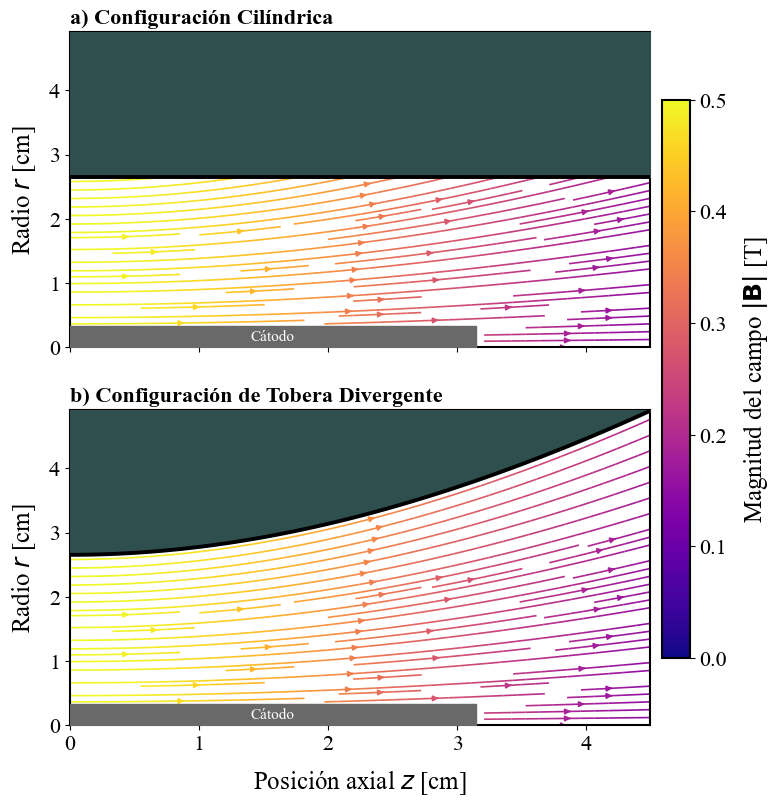

In [4]:
import numpy as np
import matplotlib.pyplot as plt

FONT_SIZE_BASE = 16
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": FONT_SIZE_BASE,
    "axes.titlesize": FONT_SIZE_BASE + 2,
    "axes.labelsize": FONT_SIZE_BASE + 2,
    "xtick.labelsize": FONT_SIZE_BASE,
    "ytick.labelsize": FONT_SIZE_BASE,
})

# Geometría en cm: usa rc/ra/Lc/La de la celda de geometría.
# NO redefinir r_c/r_a/L_c/L_a (esos son los SI que usa la sim).
A_NOZZLE = A_nozzle * 100.0   # cm  (= 'a' del C++; A_nozzle del master está en m)
B0_tesla = B0                 # T   (del master)


nz, nr = 220, 220
z = np.linspace(0, La, nz)
r = np.linspace(0, 5.0, nr)
Zg, Rg = np.meshgrid(z, r)
denom  = 1.0 + (Zg / A_NOZZLE)**2
Bz     = B0_tesla / denom**1.5
dBz_dz = -3.0 * B0_tesla * Zg / (A_NOZZLE**2 * denom**2.5)
Br     = -0.5 * Rg * dBz_dz
Bmag   = np.sqrt(Bz**2 + Br**2)

# Ocultar el interior del cátodo
cath = (Rg < rc) & (Zg <= Lc)
Bz = np.where(cath, np.nan, Bz)
Br = np.where(cath, np.nan, Br)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))

def dibujar_panel(ax, pared_z, pared_r, titulo):
    # 1) Campo (al fondo)
    strm = ax.streamplot(z, r, Bz, Br, color=Bmag, cmap='plasma', density=1.4,
                         linewidth=1.2, norm=plt.Normalize(0, 0.5), arrowsize=0.8)
    # 2) Ánodo sólido cubriendo todo el dominio superior
    ax.fill_between(pared_z, pared_r, 5.0, color='darkslategray', zorder=5)
    ax.plot(pared_z, pared_r, color='black', lw=2.8, zorder=6)

    ax.fill_between([0, Lc], 0, rc, color='dimgray', zorder=10)
    ax.text(Lc/2, rc/2, 'Cátodo', color='white', ha='center', va='center',
            fontsize=FONT_SIZE_BASE - 5, zorder=11)
    ax.set_ylabel(r"Radio $r$ [cm]", labelpad=8)
    ax.set_xlim(0, La); ax.set_ylim(0, 4.9)
    ax.set_title(titulo, fontweight='bold', loc='left', fontsize=FONT_SIZE_BASE)
    return strm

zc = np.linspace(0, La, 120)
dibujar_panel(ax1, zc, np.full_like(zc, ra), "a) Configuración Cilíndrica")
pared_div = ra * (1.0 + (zc / A_NOZZLE)**2)**0.75   # = línea de campo
strm2 = dibujar_panel(ax2, zc, pared_div, "b) Configuración de Tobera Divergente")

ax1.set_xticklabels([])
ax2.set_xlabel(r"Posición axial $z$ [cm]", labelpad=10)

cbar = fig.colorbar(strm2.lines, ax=[ax1, ax2], orientation='vertical',
                    fraction=0.045, pad=0.02)
cbar.set_label(r"Magnitud del campo $|\mathbf{B}|$ [T]", labelpad=10)

plt.savefig("campos_simetricos.pdf", bbox_inches='tight')
plt.savefig("campos_simetricos.png", dpi=300, bbox_inches='tight')
print("Figura exportada.")
plt.show()

# 4 · Modelo test-particle en campos analíticos

In [6]:
import numpy as np

def r_pared(z):
    return np.minimum(r_a*(1+(z/A_nozzle)**2)**0.75, r_a_max)

def simular(Ti_eV, V_vaina, N=4000, nsteps=400000, n_traj=70, cada_frame=CADA_FRAME, seed=1):
    np.random.seed(seed)
    rs=[]
    while len(rs)<N:
        rr=r_c+np.random.rand(N)*(r_a-r_c); rs.extend(rr[np.random.rand(N)<(r_c/rr)].tolist())
    r0=np.array(rs[:N]); th=np.random.rand(N)*2*np.pi
    x=r0*np.cos(th); y=r0*np.sin(th); z=np.random.rand(N)*L_a              # UNIFORME en el dominio
    vth=np.sqrt(e*Ti_eV/m_ion)
    u_iny=vth                                                             # haz axial = magnitud térmica
    vr=np.random.randn(N)*vth; vt=np.random.randn(N)*vth
    ex,ey=x/r0,y/r0
    vx=vr*ex - vt*ey; vy=vr*ey + vt*ex; vz=np.full(N, u_iny)              # anisótropa hacia adelante

    status=np.zeros(N,dtype=int)
    E_imp=np.zeros(N); zi=np.zeros(N); ri=np.zeros(N)
    traj=[[] for _ in range(n_traj)]; frames=[]; qm=e/m_ion

    for step in range(nsteps):
        if step%cada_frame==0:                                            # graba fotograma (animación)
            frames.append((z.copy()*100, np.sqrt(x*x+y*y)*100, status.copy()))
        if step%400==0:                                                   # graba trayectorias (figura)
            for j in range(n_traj):
                traj[j].append((z[j]*100, np.sqrt(x[j]**2+y[j]**2)*100))
        act=status==0
        if act.sum()<0.005*N: break
        idx=np.where(act)[0]
        xa,ya,za=x[idx],y[idx],z[idx]; vxa,vya,vza=vx[idx],vy[idx],vz[idx]
        r=np.maximum(np.sqrt(xa*xa+ya*ya),1e-9)
        Bz=B0/(1+(za/A_nozzle)**2)**1.5; dBz=-3*B0*za/A_nozzle**2/(1+(za/A_nozzle)**2)**2.5
        Br=-0.5*r*dBz; Bx=Br*xa/r; By=Br*ya/r
        Ex=np.zeros_like(xa);Ey=np.zeros_like(xa);Ez=np.zeros_like(xa)
        ib=(r>r_c)&(r<r_c+delta_vaina)&(za>0)&(za<L_c); Eb=V_vaina/delta_vaina
        Ex[ib]=-Eb*xa[ib]/r[ib]; Ey[ib]=-Eb*ya[ib]/r[ib]
        it=(za>L_c)&(za<L_c+delta_vaina)&(r<r_c); Ez[it]=-V_vaina/delta_vaina
        vmx=vxa+qm*Ex*dt/2;vmy=vya+qm*Ey*dt/2;vmz=vza+qm*Ez*dt/2
        tx=qm*Bx*dt/2;ty=qm*By*dt/2;tz=qm*Bz*dt/2;t2=tx*tx+ty*ty+tz*tz
        sx=2*tx/(1+t2);sy=2*ty/(1+t2);sz=2*tz/(1+t2)
        vpx=vmx+(vmy*tz-vmz*ty);vpy=vmy+(vmz*tx-vmx*tz);vpz=vmz+(vmx*ty-vmy*tx)
        vxn=vmx+(vpy*sz-vpz*sy);vyn=vmy+(vpz*sx-vpx*sz);vzn=vmz+(vpx*sy-vpy*sx)
        vxn+=qm*Ex*dt/2;vyn+=qm*Ey*dt/2;vzn+=qm*Ez*dt/2
        xn=xa+vxn*dt;yn=ya+vyn*dt;zn=za+vzn*dt;rn=np.sqrt(xn*xn+yn*yn)
        Ek=0.5*m_ion*(vxn**2+vyn**2+vzn**2)/e
        st=np.zeros(len(idx),dtype=int)
        st[zn>=L_sim]=3
        st[(zn<=0)&(st==0)]=5
        st[(rn>=r_pared(zn))&(zn>=0)&(zn<=L_a)&(st==0)]=4
        cat=(rn<=r_c)&(zn>0)&(zn<=L_c)&(st==0); side=r>r_c
        st[cat&side]=1; st[cat&(~side)]=2
        st[(za>L_c)&(zn<=L_c)&(rn<r_c)&(st==0)]=2
        x[idx]=xn;y[idx]=yn;z[idx]=zn;vx[idx]=vxn;vy[idx]=vyn;vz[idx]=vzn
        hit=(st==1)|(st==2)
        status[idx[st>0]]=st[st>0]
        E_imp[idx[hit]]=Ek[hit]; zi[idx[hit]]=zn[hit]; ri[idx[hit]]=np.minimum(rn[hit],r_c)

    frames.append((z.copy()*100, np.sqrt(x*x+y*y)*100, status.copy()))    # fotograma final
    me=(status==1)|(status==2)
    return dict(status=status, E_imp=E_imp, zi=zi, ri=ri, traj=traj, frames=frames, N=N,
        barril=100*(status==1).sum()/N, punta=100*(status==2).sum()/N,
        escape=100*(status==3).sum()/N, anodo=100*(status==4).sum()/N,
        backplate=100*(status==5).sum()/N, activo=100*(status==0).sum()/N,
        E_med=E_imp[me].mean() if me.any() else 0, carga=E_imp[me].sum())

R = simular(T_i, V_vaina)
R = simular(T_i, V_vaina)
print(f"barril {R['barril']:.1f}%   punta {R['punta']:.1f}%   escape {R['escape']:.1f}%   "
      f"anodo {R['anodo']:.1f}%   backplate {R['backplate']:.1f}%   activo {R['activo']:.1f}%")
print(f"Energia de impacto media: {R['E_med']:.1f} eV    carga termica relativa: {R['carga']:.0f}")
print(f"{len(R['frames'])} fotogramas grabados (una sola corrida)")

barril 16.4%   punta 0.2%   escape 81.8%   anodo 1.1%   backplate 0.0%   activo 0.5%
Energia de impacto media: 7.5 eV    carga termica relativa: 4944
147 fotogramas grabados (una sola corrida)


# 5 · Diagnóstico: trayectorias, bombardeo y energía de impacto

C:\Users\asus\AppData\Local\Temp\ipykernel_2468\820850217.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


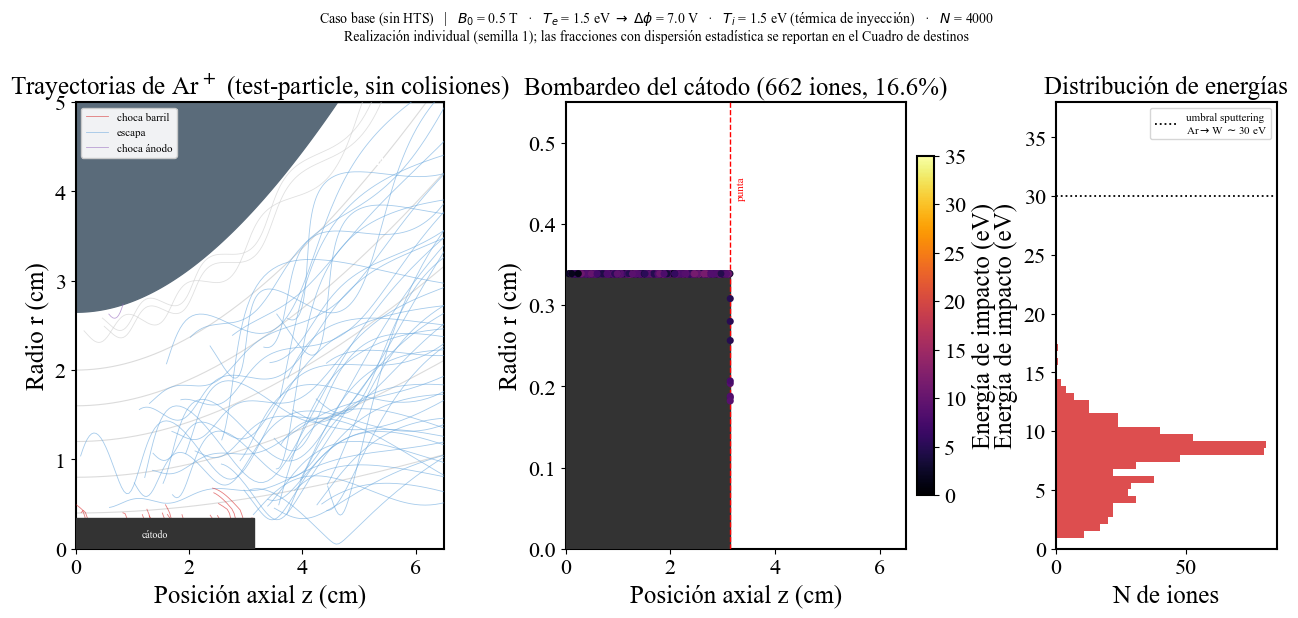

In [27]:
import numpy as np
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(15.5,5.8))
gs=fig.add_gridspec(1,3,width_ratios=[2,2,1.2],wspace=0.38)
ax1=fig.add_subplot(gs[0]); ax2=fig.add_subplot(gs[1]); ax3=fig.add_subplot(gs[2])
zz=np.linspace(0,L_sim,300)

# Panel 1: trayectorias + geometria + lineas de campo
for r0f in [0.4,0.8,1.2,1.6,2.0,2.65]:
    ax1.plot(zz*100,r0f*(1+(zz/A_nozzle)**2)**0.75,color='0.86',lw=0.8,zorder=1)
ax1.fill_between(zz*100,r_pared(zz)*100,r_a_max*100+0.5,color='#5a6b7a',zorder=2)
ax1.text(5.2,4.3,'ÁNODO',color='white',fontsize=9,weight='bold',zorder=3)
ax1.add_patch(plt.Rectangle((0,0),L_c*100,r_c*100,color='0.2',zorder=6))
ax1.text(1.4,0.13,'cátodo',color='white',fontsize=7,zorder=7,ha='center')
col={1:'#d62728',2:'#7a0010',3:'#6aa8de',4:'#9467bd',5:'#888888',0:'#cccccc'}
lab={1:'choca barril',2:'choca punta',3:'escapa',4:'choca ánodo',5:'backplate'}
seen=set()
for j,t in enumerate(R['traj']):
    if len(t)<2: continue
    arr=np.array(t); fate=R['status'][j]
    lb=lab.get(fate) if fate not in seen else None
    if fate in lab: seen.add(fate)
    ax1.plot(arr[:,0],arr[:,1],color=col[fate],lw=0.6,alpha=0.6,zorder=4,label=lb)
ax1.set_xlim(0,L_sim*100);ax1.set_ylim(0,r_a_max*100)
ax1.set_xlabel('Posición axial z (cm)');ax1.set_ylabel('Radio r (cm)')
ax1.set_title('Trayectorias de Ar$^+$ (test-particle, sin colisiones)')
ax1.legend(loc='upper left',fontsize=8,framealpha=0.92)

# Panel 2: bombardeo del catodo, color = energia
ax2.add_patch(plt.Rectangle((0,0),L_c*100,r_c*100,color='0.2',zorder=6))
me=(R['status']==1)|(R['status']==2)
sc=ax2.scatter(R['zi'][me]*100,R['ri'][me]*100,c=R['E_imp'][me],cmap='inferno',
               s=26,zorder=8,vmin=0,vmax=35,edgecolors='none')
ax2.axvline(L_c*100,color='r',ls='--',lw=1,zorder=7)
ax2.text(L_c*100+0.1,0.46,'punta',color='r',fontsize=8,rotation=90,va='top')
ax2.set_xlim(0,L_sim*100);ax2.set_ylim(0,0.55)
ax2.set_xlabel('Posición axial z (cm)');ax2.set_ylabel('Radio r (cm)')
ax2.set_title(f'Bombardeo del cátodo ({me.sum()} iones, {100*me.sum()/R["N"]:.1f}%)')
cb=plt.colorbar(sc,ax=ax2,fraction=0.046,pad=0.03); cb.set_label('Energía de impacto (eV)')

# Panel 3: histograma de energia
ax3.hist(R['E_imp'][me],bins=28,color='#d62728',alpha=0.82,orientation='horizontal')
ax3.axhline(30,color='k',ls=':',lw=1.3,label='umbral sputtering\nAr$\\to$W $\\sim$30 eV')
ax3.set_ylabel('Energía de impacto (eV)');ax3.set_xlabel('N de iones')
ax3.set_title('Distribución de energías');ax3.legend(fontsize=8,loc='upper right');ax3.set_ylim(0,38)

plt.suptitle(
    f'Caso base (sin HTS)   |   $B_0$ = {B0} T   ·   '
    f'$T_e$ = {T_e} eV $\\rightarrow$ $\\Delta\\phi$ = {V_vaina:.1f} V   ·   '
    f'$T_i$ = {T_i} eV (térmica de inyección)   ·   $N$ = {R["N"]}\n'
    f'Realización individual (semilla 1); las fracciones con dispersión estadística '
    f'se reportan en el Cuadro de destinos',
    fontsize=10, y=1.04)

plt.tight_layout()
plt.savefig('base_testparticle.png', dpi=200, bbox_inches='tight')
plt.show()

# 6 · Animación del modelo test-particle

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

Z_1D = np.linspace(0, L_sim, 300); limite_pared = r_pared(Z_1D)
fig, ax1 = plt.subplots(figsize=(10, 5), facecolor='white')
ax1.set_xlim(0, L_sim*100); ax1.set_ylim(0, r_a_max*100)
ax1.set_xlabel('Posición Axial Z (cm)', fontsize=12); ax1.set_ylabel('Radio R (cm)', fontsize=12)
ax1.fill_between([0, L_c*100], [0, 0], [r_c*100, r_c*100], color='dimgray', label='Cátodo')
ax1.fill_between(Z_1D*100, limite_pared*100, r_a_max*100, color='darkslategray', alpha=0.8, label='Ánodo')
ax1.axvline(x=L_c*100, color='red', linestyle='--', alpha=0.5, label='Punta (Z=L_c)')
scat_vivos  = ax1.scatter([], [], color='cyan',   s=10, zorder=5, label='En tránsito')
scat_barril = ax1.scatter([], [], color='red',    s=15, zorder=6, label='Colisión Barril')
scat_punta  = ax1.scatter([], [], color='purple', s=20, zorder=6, label='Colisión Punta')
scat_escape = ax1.scatter([], [], color='lime',   s=10, zorder=5, label='Eyectados')
scat_anodo  = ax1.scatter([], [], color='orange', s=12, zorder=6, label='Colisión Ánodo')
ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.15), ncol=6, fontsize=9)
titulo = ax1.set_title('', fontsize=14, fontweight='bold', pad=25)

def update(frame):
    Zp, Rp, est = R['frames'][frame]                      # solo reproduce los fotogramas de la Celda 1
    scat_vivos.set_offsets(np.column_stack((Zp[est==0], Rp[est==0])))
    scat_barril.set_offsets(np.column_stack((Zp[est==1], Rp[est==1])))
    scat_punta.set_offsets(np.column_stack((Zp[est==2], Rp[est==2])))
    scat_escape.set_offsets(np.column_stack((Zp[est==3], Rp[est==3])))
    scat_anodo.set_offsets(np.column_stack((Zp[est==4], Rp[est==4])))
    tiempo_us = (frame * CADA_FRAME * dt) * 1e6
    titulo.set_text(f"t = {tiempo_us:.2f} μs | Vivos: {np.sum(est==0)} | Escape: {np.sum(est==3)} | "
                    f"Punta: {np.sum(est==2)} | Barril: {np.sum(est==1)}")
    return scat_vivos, scat_barril, scat_punta, scat_escape, scat_anodo, titulo

print("Generando animación...")
anim = FuncAnimation(fig, update, frames=range(1, len(R['frames'])), interval=40, blit=True)

# --- Exportar a GIF ---
from matplotlib.animation import PillowWriter
anim.save("lluvia_iones_analitico.gif", writer=PillowWriter(fps=25), dpi=90)
plt.close(fig)
print("GIF guardado: lluvia_iones_analitico.gif")

Generando animación...
GIF guardado: lluvia_iones_analitico.gif


# 7 · HTS: refuerzo del campo de tobera uniforme

Barrido de B0...


  0%|          | 0/7 [00:00<?, ?it/s]

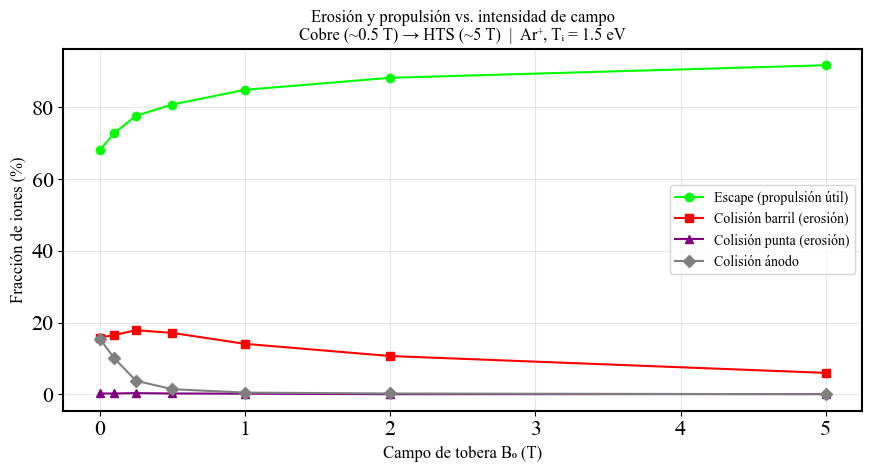


B0 (T)   Escape   Barril   Punta   Ánodo   Backpl  
-------------------------------------------------
0.00     68.0     15.8     0.2     15.5    0.0     
0.10     72.8     16.5     0.2     10.1    0.0     
0.25     77.7     17.9     0.3     3.8     0.0     
0.50     80.8     17.1     0.2     1.4     0.1     
1.00     84.9     14.1     0.1     0.5     0.0     
2.00     88.2     10.7     0.0     0.2     0.5     
5.00     91.8     6.0      0.1     0.0     1.8     


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

N_SWEEP = 2000   # iones por corrida (sube a 4000 para figuras finales; baja a 1000 si va lento)

def _coil(R, Z, Bp, z0, a):
    """Campo en eje + Br paraxial de una espira de radio a centrada en z0 (SI)."""
    dz = Z - z0
    Bz = Bp/(1+(dz/a)**2)**1.5
    dBz = -3*Bp*dz/(a**2*(1+(dz/a)**2)**2.5)
    return Bz, -0.5*R*dBz

def simular_hts(B0, cusp_B=0.0, cusp_delta=1.0e-2, cusp_a=1.5e-2, N=N_SWEEP, nsteps=300000, seed=1):
    """Test-particle: tobera (espira en z=0, intensidad B0) + cusp opcional
       (dos espiras opuestas en z=L_c ± cusp_delta). Devuelve fracciones por destino."""
    np.random.seed(seed)
    rs=[]
    while len(rs)<N:
        rr=r_c+np.random.rand(N)*(r_a-r_c); rs.extend(rr[np.random.rand(N)<(r_c/rr)].tolist())
    r0=np.array(rs[:N]); th=np.random.rand(N)*2*np.pi
    x=r0*np.cos(th); y=r0*np.sin(th); z=np.random.rand(N)*L_a
    vth=np.sqrt(e*T_i/m_ion); u_iny=vth
    vr=np.random.randn(N)*vth; vt=np.random.randn(N)*vth
    ex,ey=x/r0,y/r0
    vx=vr*ex-vt*ey; vy=vr*ey+vt*ex; vz=np.full(N,u_iny)
    status=np.zeros(N,dtype=int); E_imp=np.zeros(N); qm=e/m_ion
    for step in range(nsteps):
        act=status==0
        if act.sum()<0.005*N: break
        idx=np.where(act)[0]
        xa,ya,za=x[idx],y[idx],z[idx]; vxa,vya,vza=vx[idx],vy[idx],vz[idx]
        r=np.maximum(np.sqrt(xa*xa+ya*ya),1e-9)
        Bz=B0/(1+(za/A_nozzle)**2)**1.5; dBz=-3*B0*za/A_nozzle**2/(1+(za/A_nozzle)**2)**2.5
        Br=-0.5*r*dBz
        if cusp_B!=0.0:
            Bz1,Br1=_coil(r,za,+cusp_B,L_c-cusp_delta,cusp_a)
            Bz2,Br2=_coil(r,za,-cusp_B,L_c+cusp_delta,cusp_a)
            Bz=Bz+Bz1+Bz2; Br=Br+Br1+Br2
        Bx=Br*xa/r; By=Br*ya/r
        Ex=np.zeros_like(xa);Ey=np.zeros_like(xa);Ez=np.zeros_like(xa)
        ib=(r>r_c)&(r<r_c+delta_vaina)&(za>0)&(za<L_c); Eb=V_vaina/delta_vaina
        Ex[ib]=-Eb*xa[ib]/r[ib]; Ey[ib]=-Eb*ya[ib]/r[ib]
        it=(za>L_c)&(za<L_c+delta_vaina)&(r<r_c); Ez[it]=-V_vaina/delta_vaina
        vmx=vxa+qm*Ex*dt/2;vmy=vya+qm*Ey*dt/2;vmz=vza+qm*Ez*dt/2
        tx=qm*Bx*dt/2;ty=qm*By*dt/2;tz=qm*Bz*dt/2;t2=tx*tx+ty*ty+tz*tz
        sx=2*tx/(1+t2);sy=2*ty/(1+t2);sz=2*tz/(1+t2)
        vpx=vmx+(vmy*tz-vmz*ty);vpy=vmy+(vmz*tx-vmx*tz);vpz=vmz+(vmx*ty-vmy*tx)
        vxn=vmx+(vpy*sz-vpz*sy);vyn=vmy+(vpz*sx-vpx*sz);vzn=vmz+(vpx*sy-vpy*sx)
        vxn+=qm*Ex*dt/2;vyn+=qm*Ey*dt/2;vzn+=qm*Ez*dt/2
        xn=xa+vxn*dt;yn=ya+vyn*dt;zn=za+vzn*dt;rn=np.sqrt(xn*xn+yn*yn)
        Ek=0.5*m_ion*(vxn**2+vyn**2+vzn**2)/e
        st=np.zeros(len(idx),dtype=int)
        st[zn>=L_sim]=3; st[(zn<=0)&(st==0)]=5
        st[(rn>=r_pared(zn))&(zn>=0)&(zn<=L_a)&(st==0)]=4
        cat=(rn<=r_c)&(zn>0)&(zn<=L_c)&(st==0); side=r>r_c
        st[cat&side]=1; st[cat&(~side)]=2
        st[(za>L_c)&(zn<=L_c)&(rn<r_c)&(st==0)]=2
        x[idx]=xn;y[idx]=yn;z[idx]=zn;vx[idx]=vxn;vy[idx]=vyn;vz[idx]=vzn
        hit=(st==1)|(st==2); status[idx[st>0]]=st[st>0]; E_imp[idx[hit]]=Ek[hit]
    f=lambda k:100*(status==k).sum()/N
    me=(status==1)|(status==2)
    return dict(escape=f(3), barril=f(1), punta=f(2), anodo=f(4),
                backplate=f(5), atrapados=f(0),
                E_med=E_imp[me].mean() if me.any() else 0.0)

# ===== Barrido de intensidad de campo: cobre (~0.5 T) -> HTS (~5 T) =====
valores_B0 = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
print("Barrido de B0..."); res_B0 = [simular_hts(b, cusp_B=0.0) for b in tqdm(valores_B0)]

esc=[r['escape'] for r in res_B0]; bar=[r['barril'] for r in res_B0]
pun=[r['punta'] for r in res_B0]; ano=[r['anodo'] for r in res_B0]

fig, ax = plt.subplots(figsize=(9,5), facecolor='white')
ax.plot(valores_B0, esc, 'o-', color='lime',   label='Escape (propulsión útil)')
ax.plot(valores_B0, bar, 's-', color='red',    label='Colisión barril (erosión)')
ax.plot(valores_B0, pun, '^-', color='purple', label='Colisión punta (erosión)')
ax.plot(valores_B0, ano, 'D-', color='gray',   label='Colisión ánodo')
ax.set_xlabel('Campo de tobera B₀ (T)', fontsize=12)
ax.set_ylabel('Fracción de iones (%)', fontsize=12)
ax.set_title('Erosión y propulsión vs. intensidad de campo\n'
             'Cobre (~0.5 T) → HTS (~5 T)  |  Ar⁺, Tᵢ = 1.5 eV', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'B0 (T)':<9}{'Escape':<9}{'Barril':<9}{'Punta':<8}{'Ánodo':<8}{'Backpl':<8}")
print("-"*49)
for b,r in zip(valores_B0,res_B0):
    print(f"{b:<9.2f}{r['escape']:<9.1f}{r['barril']:<9.1f}{r['punta']:<8.1f}{r['anodo']:<8.1f}{r['backplate']:<8.1f}")

# 8 · HTS: topología de cusp magnético

Barrido de cusp...


  0%|          | 0/6 [00:00<?, ?it/s]

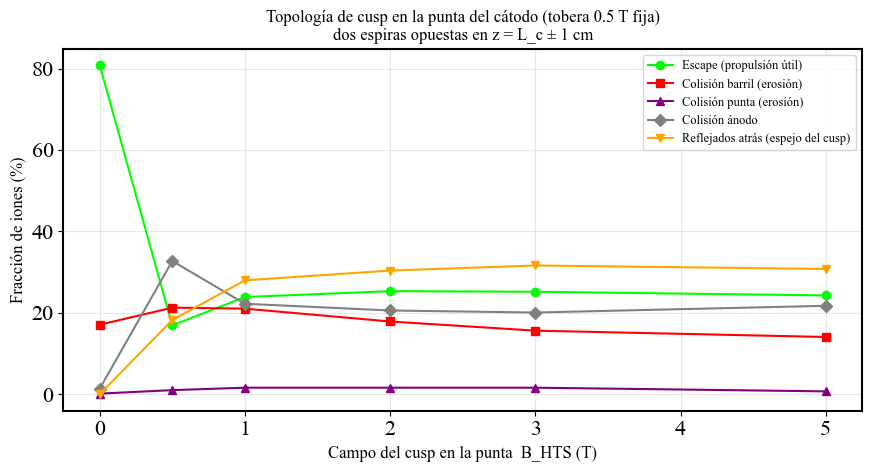


B_HTS (T)  Escape   Barril   Punta   Ánodo   Backpl  Atrap   
-----------------------------------------------------------
0.0        80.8     17.1     0.2     1.4     0.1     0.5     
0.5        16.9     21.3     1.1     32.8    18.2    9.7     
1.0        23.9     21.1     1.6     22.2    28.0    3.1     
2.0        25.4     17.9     1.6     20.6    30.4    4.1     
3.0        25.2     15.7     1.6     20.1    31.6    5.8     
5.0        24.3     14.1     0.8     21.8    30.8    8.3     


In [10]:
# ===== Fuerza del cusp (tobera fija 0.5 T + dos espiras opuestas en z = L_c ± 1 cm) =====
valores_cusp = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
print("Barrido de cusp..."); res_cusp = [simular_hts(0.5, cusp_B=cb) for cb in tqdm(valores_cusp)]

esc=[r['escape'] for r in res_cusp]; bar=[r['barril'] for r in res_cusp]
pun=[r['punta'] for r in res_cusp]; ano=[r['anodo'] for r in res_cusp]; bpl=[r['backplate'] for r in res_cusp]

fig, ax = plt.subplots(figsize=(9,5), facecolor='white')
ax.plot(valores_cusp, esc, 'o-', color='lime',   label='Escape (propulsión útil)')
ax.plot(valores_cusp, bar, 's-', color='red',    label='Colisión barril (erosión)')
ax.plot(valores_cusp, pun, '^-', color='purple', label='Colisión punta (erosión)')
ax.plot(valores_cusp, ano, 'D-', color='gray',   label='Colisión ánodo')
ax.plot(valores_cusp, bpl, 'v-', color='orange', label='Reflejados atrás (espejo del cusp)')
ax.set_xlabel('Campo del cusp en la punta  B_HTS (T)', fontsize=12)
ax.set_ylabel('Fracción de iones (%)', fontsize=12)
ax.set_title('Topología de cusp en la punta del cátodo (tobera 0.5 T fija)\n'
             'dos espiras opuestas en z = L_c ± 1 cm', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'B_HTS (T)':<11}{'Escape':<9}{'Barril':<9}{'Punta':<8}{'Ánodo':<8}{'Backpl':<8}{'Atrap':<8}")
print("-"*59)
for b,r in zip(valores_cusp,res_cusp):
    print(f"{b:<11.1f}{r['escape']:<9.1f}{r['barril']:<9.1f}{r['punta']:<8.1f}{r['anodo']:<8.1f}{r['backplate']:<8.1f}{r['atrapados']:<8.1f}")

# 9 · Comparación de las tres topologías

C:\Users\asus\AppData\Local\Temp\ipykernel_2468\1027071033.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


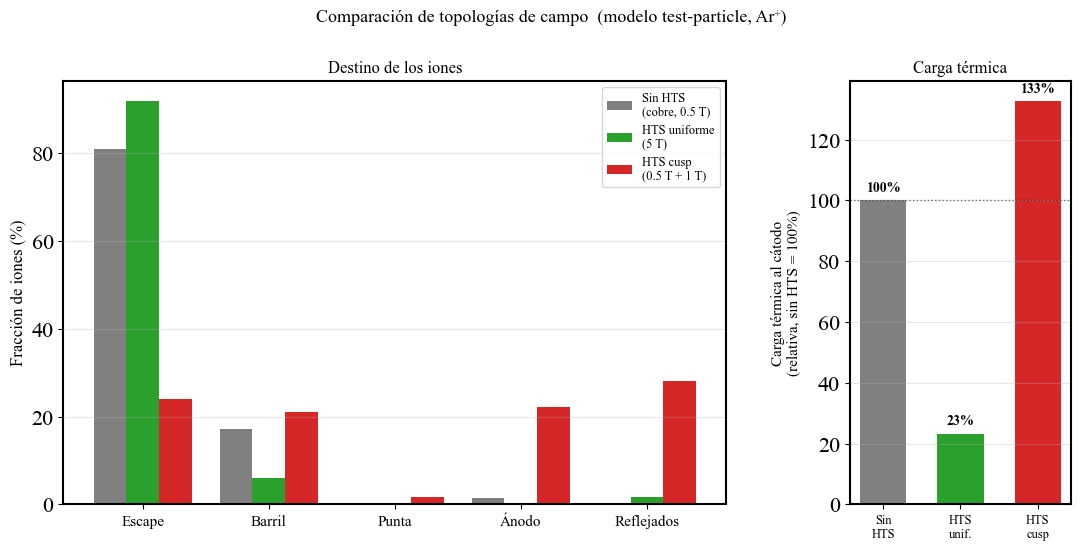


Configuración         Escape   Barril   Punta   Ánodo   Backpl  E_imp(eV)  Carga rel.
--------------------------------------------------------------------------------------------
Sin HTS (cobre, 0.5 T)80.8     17.1     0.2     1.4     0.1     7.6        100%
HTS uniforme (5 T)    91.8     6.0      0.1     0.0     1.8     5.1        23%
HTS cusp (0.5 T + 1 T)23.9     21.1     1.6     22.2    28.0    7.7        133%


In [11]:
# ===== Sin HTS  vs  HTS uniforme  vs  HTS cusp =====
configs = {
    'Sin HTS\n(cobre, 0.5 T)': res_B0[valores_B0.index(0.5)],
    'HTS uniforme\n(5 T)':      res_B0[valores_B0.index(5.0)],
    'HTS cusp\n(0.5 T + 1 T)':  res_cusp[valores_cusp.index(1.0)],
}
col_cfg = ['#808080', '#2ca02c', '#d62728']   # gris / verde / rojo

# Carga térmica al cátodo = (% que golpea el cátodo) x (energía media de impacto).
# Proxy del flujo de energía depositada; la erosión real es por evaporación (ver texto).
carga     = {lab: (r['barril']+r['punta'])*r['E_med'] for lab,r in configs.items()}
ref       = list(carga.values())[0]                    # sin HTS = 100%
carga_rel = {lab: 100*c/ref for lab,c in carga.items()}

metricas = ['escape','barril','punta','anodo','backplate']
nombres  = ['Escape','Barril','Punta','Ánodo','Reflejados']

fig = plt.figure(figsize=(13, 5.5), facecolor='white')
gs  = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.28)
ax1 = fig.add_subplot(gs[0]); ax2 = fig.add_subplot(gs[1])

x = np.arange(len(metricas)); w = 0.26
for i,(lab,r) in enumerate(configs.items()):
    ax1.bar(x+(i-1)*w, [r[mt] for mt in metricas], w, label=lab, color=col_cfg[i])
ax1.set_xticks(x); ax1.set_xticklabels(nombres, fontsize=11)
ax1.set_ylabel('Fracción de iones (%)', fontsize=12)
ax1.set_title('Destino de los iones', fontsize=12)
ax1.legend(fontsize=9); ax1.grid(True, axis='y', alpha=0.3)

ax2.bar(range(3), list(carga_rel.values()), color=col_cfg, width=0.6)
ax2.axhline(100, color='k', ls=':', lw=1, alpha=0.5)
ax2.set_xticks(range(3)); ax2.set_xticklabels(['Sin\nHTS','HTS\nunif.','HTS\ncusp'], fontsize=9)
ax2.set_ylabel('Carga térmica al cátodo\n(relativa, sin HTS = 100%)', fontsize=11)
ax2.set_title('Carga térmica', fontsize=12)
for i,v in enumerate(carga_rel.values()):
    ax2.text(i, v+3, f'{v:.0f}%', ha='center', fontsize=10, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

fig.suptitle('Comparación de topologías de campo  (modelo test-particle, Ar⁺)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"\n{'Configuración':<22}{'Escape':<9}{'Barril':<9}{'Punta':<8}{'Ánodo':<8}{'Backpl':<8}{'E_imp(eV)':<11}{'Carga rel.'}")
print("-"*92)
for lab,r in configs.items():
    l = lab.replace('\n',' ')
    print(f"{l:<22}{r['escape']:<9.1f}{r['barril']:<9.1f}{r['punta']:<8.1f}"
          f"{r['anodo']:<8.1f}{r['backplate']:<8.1f}{r['E_med']:<11.1f}{carga_rel[l[:0]+lab]:.0f}%" if False else
          f"{l:<22}{r['escape']:<9.1f}{r['barril']:<9.1f}{r['punta']:<8.1f}"
          f"{r['anodo']:<8.1f}{r['backplate']:<8.1f}{r['E_med']:<11.1f}{carga_rel[lab]:.0f}%")

# 10 · Estudio de semillas

Repite la simulación con semillas independientes del generador aleatorio, de modo que
los resultados puedan reportarse como media ± desviación estándar en lugar de valores
de una corrida única.

In [12]:
def estudio_semillas(n_seeds=10, N=4000, Ti=None, Vv=None):
    """Corre `simular` con semillas 1..n_seeds y reporta media ± desv.
    Devuelve el dict de listas por si quieres graficar o tabular."""
    Ti = T_i if Ti is None else Ti
    Vv = V_vaina if Vv is None else Vv
    keys = ['barril', 'punta', 'escape', 'anodo', 'backplate', 'E_med', 'carga']
    res = {k: [] for k in keys}
    for seed in range(1, n_seeds + 1):
        R = simular(Ti, Vv, N=N, seed=seed)
        for k in keys:
            res[k].append(R[k])
        print(f"seed {seed:2d}: barril {R['barril']:5.1f}%  escape {R['escape']:5.1f}%  "
              f"anodo {R['anodo']:4.1f}%  E={R['E_med']:.2f} eV")
    print(f"\n--- MEDIA ± DESV ({n_seeds} semillas, N={N}) ---")
    for k in keys:
        a = np.array(res[k])
        print(f"  {k:>10}: {a.mean():8.2f} ± {a.std(ddof=1):.2f}")
    return res

# 11 · Flujo de calor iónico sobre el cátodo

Convierte los impactos registrados por el modelo cinético en la carga térmica
distribuida sobre la superficie, separando la contribución cinética de la de
recombinación.

In [13]:
PHI_W = 4.55      # eV — función de trabajo del tungsteno
 
def flujo_calor(R, mdot=None, phi_W=None, nbins=10):
    """Escala las partículas de prueba al flujo físico y calcula:
    Q_kin, Q_rec, Q_tot [W] y el perfil axial q(z) [W/cm²] sobre el barril.
    mdot: si no se pasa, lee mdot_kgs de la celda 3 (única fuente de verdad,
    se actualiza sola si cambias I_lab o la geometría). Pásalo explícito
    SOLO para estudios de sensibilidad (p. ej. utilización másica < 100%)."""
    mdot  = mdot_kgs if mdot is None else mdot      # ← celda 3, no un número congelado
    phi_W = PHI_W if phi_W is None else phi_W
    w = (mdot / m_ion) / R['N']                     # iones físicos/s por partícula
    hit = (R['status'] == 1) | (R['status'] == 2)
    E_rec = V_ion - phi_W                           # eV por ion neutralizado
    Q_kin = R['E_imp'][hit].sum() * w * e
    Q_rec = hit.sum() * E_rec * w * e
    Q_tot = Q_kin + Q_rec
 
    barril = R['status'] == 1
    bins = np.linspace(0, L_c, nbins + 1)
    cnt, _  = np.histogram(R['zi'][barril], bins=bins)
    Ekin, _ = np.histogram(R['zi'][barril], bins=bins, weights=R['E_imp'][barril])
    area_cm2 = 2 * np.pi * r_c * (bins[1] - bins[0]) * 1e4
    q_z = (Ekin + cnt * E_rec) * w * e / area_cm2   # W/cm²
 
    print(f"Iones al cátodo: {hit.sum()*w:.2e} /s  ({100*hit.sum()/R['N']:.1f}%)")
    print(f"Q cinético {Q_kin:.2f} W  +  Q recombinación {Q_rec:.2f} W  =  {Q_tot:.2f} W")
    print(f"q(z) promedio barril: {Q_tot/(2*np.pi*r_c*L_c*1e4):.2f} W/cm²")
    print(f"[Contexto — NO capturado por el modelo cinético: anclaje del arco "
          f"en la punta ~ I·V_c ≈ 222 A × (5–10 V) ≈ 1.1–2.2 kW]")
    return dict(Q_kin=Q_kin, Q_rec=Q_rec, Q_tot=Q_tot, bins=bins, q_z=q_z, w=w)

# 12 · Exportación de impactos

Escribe los impactos a CSV: es la interfaz entre el modelo cinético y el solver
térmico del cátodo.

In [14]:
import csv
 
def exportar_impactos(R, nombre='impactos_base.csv', **meta):
    """Guarda por ion: status, z_impacto, r_impacto, E_impacto [eV].
    Los kwargs (B0, Te, seed, ...) quedan como metadatos en el encabezado."""
    with open(nombre, 'w', newline='') as f:
        wcsv = csv.writer(f)
        wcsv.writerow([f"# {k}={v}" for k, v in meta.items()])
        wcsv.writerow(['status', 'zi_m', 'ri_m', 'E_imp_eV'])
        for s, zi, ri, Ei in zip(R['status'], R['zi'], R['ri'], R['E_imp']):
            wcsv.writerow([int(s), f"{zi:.6e}", f"{ri:.6e}", f"{Ei:.4f}"])
    print(f"→ {nombre}: {len(R['status'])} iones exportados")

# 13 · Ejecución del diagnóstico térmico

Calcula el flujo de calor instantáneo, exporta el CSV de impactos y lanza el estudio
sobre diez semillas.

In [15]:
FC = flujo_calor(R)                              # instantáneo → los watts y q(z)
exportar_impactos(R, B0=B0, Te=T_e, Ti=T_i, seed=1)   # instantáneo → el CSV
res_base = estudio_semillas()                    # ~3.5 min → las 10 semillas

Iones al cátodo: 2.90e+18 /s  (16.6%)
Q cinético 3.47 W  +  Q recombinación 5.21 W  =  8.68 W
q(z) promedio barril: 1.30 W/cm²
[Contexto — NO capturado por el modelo cinético: anclaje del arco en la punta ~ I·V_c ≈ 222 A × (5–10 V) ≈ 1.1–2.2 kW]
→ impactos_base.csv: 4000 iones exportados
seed  1: barril  16.4%  escape  81.8%  anodo  1.1%  E=7.47 eV
seed  2: barril  15.7%  escape  82.1%  anodo  1.4%  E=7.56 eV
seed  3: barril  16.1%  escape  81.7%  anodo  1.4%  E=7.56 eV
seed  4: barril  16.5%  escape  81.6%  anodo  1.3%  E=7.76 eV
seed  5: barril  16.5%  escape  81.6%  anodo  1.1%  E=7.56 eV
seed  6: barril  16.9%  escape  80.8%  anodo  1.4%  E=7.71 eV
seed  7: barril  16.6%  escape  81.2%  anodo  1.5%  E=7.35 eV
seed  8: barril  16.3%  escape  81.7%  anodo  1.2%  E=7.61 eV
seed  9: barril  16.0%  escape  82.2%  anodo  1.3%  E=7.63 eV
seed 10: barril  17.4%  escape  80.5%  anodo  1.4%  E=7.37 eV

--- MEDIA ± DESV (10 semillas, N=4000) ---
      barril:    16.43 ± 0.48
       punta:    

# 14 · Convergencia en el número de partículas y barrido de $T_e$

Verifica que los resultados no dependan del tamaño de la muestra y caracteriza la
sensibilidad frente a la temperatura electrónica, cuya perilla física es la caída de
vaina.

In [16]:
# --- Convergencia en N (5 semillas por punto) ---
for N in [2000, 4000, 8000]:
    print(f"\n########## N = {N} ##########")
    estudio_semillas(n_seeds=5, N=N)

# --- Barrido de T_e (la perilla es V_vaina ≈ 4.7·T_e) ---
for Te in [1.0, 2.0, 3.0, 5.0]:
    Vv = (Te/2)*np.log(m_ion/(2*np.pi*m_e))
    print(f"\n########## T_e = {Te} eV  →  V_vaina = {Vv:.1f} V ##########")
    estudio_semillas(n_seeds=5, Vv=Vv)


########## N = 2000 ##########
seed  1: barril  17.1%  escape  80.8%  anodo  1.4%  E=7.59 eV
seed  2: barril  16.1%  escape  81.7%  anodo  1.7%  E=7.33 eV
seed  3: barril  15.1%  escape  82.5%  anodo  1.7%  E=7.62 eV
seed  4: barril  17.6%  escape  80.5%  anodo  1.1%  E=7.57 eV
seed  5: barril  14.8%  escape  83.0%  anodo  1.6%  E=7.66 eV

--- MEDIA ± DESV (5 semillas, N=2000) ---
      barril:    16.14 ± 1.24
       punta:     0.22 ± 0.08
      escape:    81.68 ± 1.08
       anodo:     1.50 ± 0.23
   backplate:     0.01 ± 0.02
       E_med:     7.55 ± 0.13
       carga:  2471.43 ± 186.73

########## N = 4000 ##########
seed  1: barril  16.4%  escape  81.8%  anodo  1.1%  E=7.47 eV
seed  2: barril  15.7%  escape  82.1%  anodo  1.4%  E=7.56 eV
seed  3: barril  16.1%  escape  81.7%  anodo  1.4%  E=7.56 eV
seed  4: barril  16.5%  escape  81.6%  anodo  1.3%  E=7.76 eV
seed  5: barril  16.5%  escape  81.6%  anodo  1.1%  E=7.56 eV

--- MEDIA ± DESV (5 semillas, N=4000) ---
      barril:    1

# 15 · Cola de la distribución de energía

En el extremo superior del rango de $T_e$ medido experimentalmente, examina qué
fracción de los impactos supera el umbral de pulverización del tungsteno.

In [17]:
# --- Cola de la distribución a T_e = 5 eV: ¿alguien cruza el umbral? ---
Te = 5.0
Vv = (Te/2)*np.log(m_ion/(2*np.pi*m_e))
R5 = simular(T_i, Vv, seed=1)
hit = (R5['status']==1) | (R5['status']==2)
E = R5['E_imp'][hit]
print(f"T_e={Te} eV | media {E.mean():.1f} eV | máx {E.max():.1f} eV | "
      f"sobre 30 eV: {100*np.mean(E>30):.2f}% de los impactos")

# --- Y para nunca más perder resultados por truncamiento: ---
import pickle
pickle.dump(dict(Te=Te, E_imp=E), open('cola_Te5.pkl','wb'))

T_e=5.0 eV | media 19.2 eV | máx 33.3 eV | sobre 30 eV: 0.89% de los impactos


# 16 · Energética del bombardeo frente a la temperatura electrónica

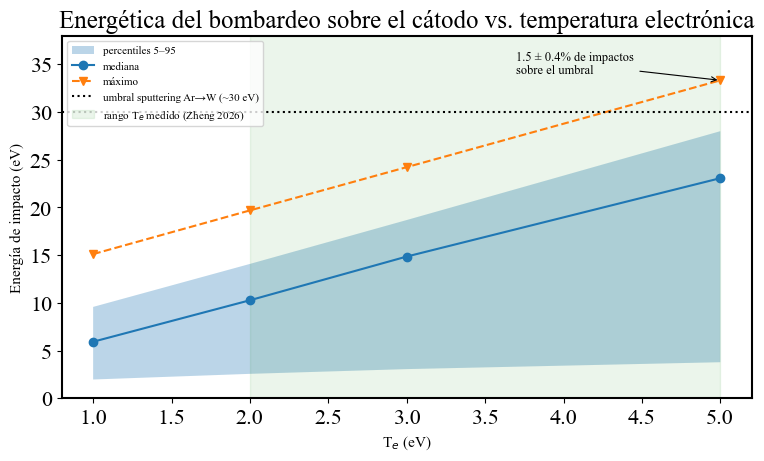

In [18]:
import matplotlib.pyplot as plt
Tes = [1.0, 2.0, 3.0, 5.0]; dist = {}
for Te in Tes:
    Vv = (Te/2)*np.log(m_ion/(2*np.pi*m_e))
    Rt = simular(T_i, Vv, seed=1)
    h = (Rt['status']==1)|(Rt['status']==2)
    dist[Te] = Rt['E_imp'][h]

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)   # ← clave 1
ax.fill_between(Tes, [np.percentile(dist[t], 5) for t in Tes],
                     [np.percentile(dist[t], 95) for t in Tes],
                alpha=0.3, label='percentiles 5–95')
ax.plot(Tes, [np.median(dist[t]) for t in Tes], 'o-', label='mediana')
ax.plot(Tes, [dist[t].max() for t in Tes], 'v--', label='máximo')
ax.axhline(30, color='k', ls=':', lw=1.5, label='umbral sputtering Ar→W (~30 eV)')
ax.axvspan(2, 5, alpha=0.08, color='green', label='rango T$_e$ medido (Zheng 2026)')

ax.annotate('1.5 ± 0.4% de impactos\nsobre el umbral',              # ← estadística
            xy=(5.0, dist[5.0].max()), xytext=(3.7, 34), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8))

ax.set_xlabel('T$_e$ (eV)', fontsize=11)
ax.set_ylabel('Energía de impacto (eV)', fontsize=11)
ax.set_ylim(0, 38)
ax.set_title('Energética del bombardeo sobre el cátodo vs. temperatura electrónica')
ax.legend(fontsize=8, loc='upper left')
plt.savefig('energetica_vs_Te.png', dpi=200, bbox_inches='tight')    # ← clave 2
plt.show()

# 17 · Tabla HTS con estadística sobre semillas

Compara el campo base de cobre con el refuerzo HTS uniforme, esta vez promediando
sobre semillas independientes e incluyendo la recombinación.

In [19]:
# --- Tabla HTS revisada: semillas + recombinación (déjalo corriendo, ~25 min) ---
resultados_hts = {}
for B in [0.5, 5.0]:          # base (cobre) vs HTS uniforme
    globals()['B0'] = B       # simular lee B0 del namespace
    print(f"\n########## B0 = {B} T ##########")
    resultados_hts[B] = estudio_semillas(n_seeds=5)
globals()['B0'] = 0.5         # restaurar


########## B0 = 0.5 T ##########
seed  1: barril  16.4%  escape  81.8%  anodo  1.1%  E=7.47 eV
seed  2: barril  15.7%  escape  82.1%  anodo  1.4%  E=7.56 eV
seed  3: barril  16.1%  escape  81.7%  anodo  1.4%  E=7.56 eV
seed  4: barril  16.5%  escape  81.6%  anodo  1.3%  E=7.76 eV
seed  5: barril  16.5%  escape  81.6%  anodo  1.1%  E=7.56 eV

--- MEDIA ± DESV (5 semillas, N=4000) ---
      barril:    16.24 ± 0.37
       punta:     0.26 ± 0.10
      escape:    81.77 ± 0.21
       anodo:     1.27 ± 0.16
   backplate:     0.00 ± 0.00
       E_med:     7.58 ± 0.11
       carga:  5000.94 ± 125.11

########## B0 = 5.0 T ##########
seed  1: barril   6.7%  escape  90.7%  anodo  0.0%  E=5.44 eV
seed  2: barril   6.1%  escape  91.6%  anodo  0.0%  E=5.27 eV
seed  3: barril   5.5%  escape  91.6%  anodo  0.1%  E=5.11 eV
seed  4: barril   5.6%  escape  92.0%  anodo  0.1%  E=5.24 eV
seed  5: barril   6.0%  escape  91.3%  anodo  0.0%  E=5.07 eV

--- MEDIA ± DESV (5 semillas, N=4000) ---
      barril: 

# 18 · Solver térmico del cátodo

Conducción unidimensional alimentada por la carga térmica del modelo cinético. El
cierre del balance energético de la superficie se impone mediante la condición de
emisión termoiónica de Richardson-Dushman.

In [20]:
import csv as _csv
from scipy.optimize import fsolve, brentq
# --- Constantes del material / superficie ---
SIGMA_SB, T_AMB = 5.6704e-8, 300.0
M_W, RHO_W, T_MELT = 183.84*1.66054e-27, 19250.0, 3695.0    # ρ: Lassner & Schubert (19.25 g/cm³)
KB, KB_EV = 1.380649e-23, 8.617e-5

# --- Propiedades del W según Lassner & Schubert (1999) ---
_TK = np.array([300,1000,1500,2000,2500,3000,3500,3695])
k_W = lambda T: np.interp(np.clip(T,300,3695), _TK,
                          [174,118,107,100,95,91,88,87])    # W/m/K — Tabla 1.14

def eps_W(T):   # emisividad hemisférica total — ec. empírica (válida 400–3600 K)
    Tc = np.clip(T, 400.0, 3600.0)
    return -2.6875e-2 + 1.819696e-4*Tc - 2.1946163e-8*Tc**2

p_vap = lambda T: 10**(12.8767 - 45395.0/np.clip(T,1200,None))   # Pa — válida 2600–3100 K
 
def cargar_q_z(csv_impactos, z_nodos, phi):
    """Reconstruye q(z) [W/m²] sobre el barril desde el CSV de exportar_impactos."""
    st, zi, Ei = [], [], []
    with open(csv_impactos) as f:
        for row in _csv.reader(f):
            if not row or row[0].startswith('#') or row[0] == 'status':
                continue
            st.append(int(row[0])); zi.append(float(row[1])); Ei.append(float(row[3]))
    st, zi, Ei = map(np.array, (st, zi, Ei))
    w = (mdot_kgs/m_ion)/len(st)
    b = st == 1
    bins = np.linspace(0, L_c, 11)
    cnt,_ = np.histogram(zi[b], bins=bins)
    Ek,_  = np.histogram(zi[b], bins=bins, weights=Ei[b])
    q = (Ek + cnt*(V_ion - phi))*w*e/(2*np.pi*r_c*(bins[1]-bins[0]))
    return np.interp(z_nodos, 0.5*(bins[:-1]+bins[1:]), q)
 
def resolver_T(Vc_eff, T_base, phi=4.55, csv_impactos='impactos_base.csv',
               I=None, N_nodos=201):
    """Perfil estacionario T(z): diferencias finitas + Newton (fsolve)."""
    I = I_lab if I is None else I
    A, P = np.pi*r_c**2, 2*np.pi*r_c
    z = np.linspace(0, L_c, N_nodos); dz = z[1]-z[0]
    q_z = cargar_q_z(csv_impactos, z, phi)
    Q_tip = I*Vc_eff
    def residuo(T):
        T = np.clip(T, 300, 7000)
        r = np.zeros(N_nodos); r[0] = T[0]-T_base
        km  = k_W(0.5*(T[:-1]+T[1:]))
        rad = eps_W(T)*SIGMA_SB*(T**4 - T_AMB**4)
        r[1:-1] = (km[1:]*(T[2:]-T[1:-1]) - km[:-1]*(T[1:-1]-T[:-2]))*A/dz**2 \
                  - P*(rad[1:-1]-q_z[1:-1])
        r[-1] = km[-1]*(T[-2]-T[-1])*A/dz + Q_tip - rad[-1]*A \
                - rad[-1]*P*dz/2 + q_z[-1]*P*dz/2
        return r
    Tg = T_base + (3200-T_base)*(z/L_c)**1.5
    T,_,ier,_ = fsolve(residuo, Tg, full_output=True)
    return (z, T) if ier == 1 else (z, None)
 
def corriente_emitida(z, T, phi, A_G):
    """Richardson-Dushman integrada sobre lateral + cara de punta [A]."""
    A, P = np.pi*r_c**2, 2*np.pi*r_c
    J = A_G*T**2*np.exp(-phi/(KB_EV*T))
    return np.trapezoid(J*P, z) + J[-1]*A
 
def tasa_evaporacion(z, T):
    """Hertz-Knudsen-Langmuir → kg/s. COTA SUPERIOR (difusión la reduce)."""
    A, P = np.pi*r_c**2, 2*np.pi*r_c
    flux = p_vap(T)*np.sqrt(M_W/(2*np.pi*KB*T))
    return np.trapezoid(flux*P, z) + flux[-1]*A
 
def cierre_richardson(phi, A_G, T_base=800.0, csv_impactos='impactos_base.csv'):
    """Busca V_c tal que la emisión termoiónica iguale I_lab. Reporta todo."""
    def deficit(Vc):
        z, T = resolver_T(Vc, T_base, phi=phi, csv_impactos=csv_impactos)
        return corriente_emitida(z, T, phi, A_G) - I_lab if T is not None else -I_lab
    Vc = brentq(deficit, 0.5, 4.5, xtol=1e-3)
    z, T = resolver_T(Vc, T_base, phi=phi, csv_impactos=csv_impactos)
    mev = tasa_evaporacion(z, T)
    masa = RHO_W*np.pi*r_c**2*L_c
    vida10_h = 0.10*masa/mev/3600
    print(f"φ={phi} eV | V_c = {Vc:.2f} V | T_punta = {T[-1]:.0f} K "
          f"({'FUNDIDO' if T[-1]>T_MELT else f'{T_MELT-T[-1]:.0f} K bajo fusión'}) | "
          f"evap {mev*3.6e6:.2e} g/h | 10% masa: {vida10_h:.2e} h "
          f"({vida10_h/8760:.2f} años)")
    return dict(Vc=Vc, z=z, T=T, evap_kgs=mev, vida10_h=vida10_h)

# 19 · Cierre termoiónico: temperatura de operación y vida útil

Resuelve la temperatura a la que cada emisor sostiene la corriente del arco, y de ahí
obtiene la tasa de evaporación y la vida útil. Se evalúan tungsteno puro y tungsteno
toriado.

In [21]:
op_puro    = cierre_richardson(phi=4.55, A_G=60e4)   # W puro
op_toriado = cierre_richardson(phi=2.63, A_G=3e4)    # W toriado (ThO2)

φ=4.55 eV | V_c = 3.33 V | T_punta = 3623 K (72 K bajo fusión) | evap 3.94e-01 g/h | 10% masa: 5.53e+00 h (0.00 años)
φ=2.63 eV | V_c = 1.62 V | T_punta = 2706 K (989 K bajo fusión) | evap 2.66e-05 g/h | 10% masa: 8.21e+04 h (9.38 años)


# 20 · Barridos finales

Cusp con estadística de semillas, cola de sputtering a la temperatura electrónica
máxima medida, y sensibilidad frente al espesor de vaina y a la temperatura de base.

In [22]:

# (1) Cusp con estadistica de semillas: tobera 0.5 T + cusp 1 T
print("###### CUSP (tobera 0.5 T + cusp 1 T) ######")
res_cusp = []
for s in range(1, 6):
    r = simular_hts(0.5, cusp_B=1.0, N=4000, seed=s)
    res_cusp.append(r)
    print(f"seed {s}: " + "  ".join(f"{k} {r[k]:.1f}%" for k in
          ['escape','barril','punta','anodo','backplate','atrapados'] if k in r))

print("\n--- MEDIA ± DESV (5 semillas, N=4000, cusp 0.5+1 T) ---")
import numpy as np
for k in res_cusp[0]:
    try:
        a = np.array([float(r[k]) for r in res_cusp])
        print(f"  {k:>10}: {a.mean():8.2f} ± {a.std(ddof=1):.2f}")
    except (TypeError, ValueError):
        pass   # salta llaves no escalares (arrays, frames, etc.)

# (2) Cola de sputtering a Te=5 eV, 5 semillas
print("\n###### COLA >30 eV a Te=5 ######")
Vv5 = (5.0/2)*np.log(m_ion/(2*np.pi*m_e))
colas = []
for s in range(1, 6):
    Rt = simular(T_i, Vv5, seed=s)
    Eh = Rt['E_imp'][(Rt['status']==1)|(Rt['status']==2)]
    colas.append(100*np.mean(Eh > 30))
print(f"sobre umbral: {np.mean(colas):.2f} ± {np.std(colas, ddof=1):.2f} %")

# (3) delta_vaina: 0.5 / 1 / 2 mm (ajusta el nombre si difiere en tu celda 1)
for dv in [0.5e-3, 1.0e-3, 2.0e-3]:
    globals()['delta_vaina'] = dv
    print(f"\n###### delta_vaina = {dv*1000:.1f} mm ######")
    estudio_semillas(n_seeds=3)
globals()['delta_vaina'] = 1.0e-3

# (4) T_base en el solver
for Tb in [600, 800, 1000]:
    print(f"\n--- T_base = {Tb} K ---")
    cierre_richardson(phi=4.55, A_G=60e4, T_base=Tb)
    cierre_richardson(phi=2.63, A_G=3e4,  T_base=Tb)

###### CUSP (tobera 0.5 T + cusp 1 T) ######
seed 1: escape 23.4%  barril 19.9%  punta 1.2%  anodo 24.0%  backplate 28.2%  atrapados 3.2%
seed 2: escape 25.6%  barril 19.7%  punta 1.6%  anodo 23.3%  backplate 26.4%  atrapados 3.5%
seed 3: escape 24.5%  barril 20.3%  punta 1.2%  anodo 22.6%  backplate 27.9%  atrapados 3.4%
seed 4: escape 24.9%  barril 21.1%  punta 1.4%  anodo 23.2%  backplate 25.9%  atrapados 3.5%
seed 5: escape 23.9%  barril 21.6%  punta 1.1%  anodo 23.1%  backplate 26.4%  atrapados 3.9%

--- MEDIA ± DESV (5 semillas, N=4000, cusp 0.5+1 T) ---
      escape:    24.44 ± 0.86
      barril:    20.54 ± 0.79
       punta:     1.32 ± 0.18
       anodo:    23.24 ± 0.49
   backplate:    26.97 ± 1.00
   atrapados:     3.50 ± 0.25
       E_med:     7.82 ± 0.15

###### COLA >30 eV a Te=5 ######
sobre umbral: 1.46 ± 0.44 %

###### delta_vaina = 0.5 mm ######
seed  1: barril  13.3%  escape  85.0%  anodo  1.1%  E=8.26 eV
seed  2: barril  12.5%  escape  85.4%  anodo  1.4%  E=8.29 eV
s

# 21 · Resultados consolidados

Estado congelado del análisis estadístico y térmico del modelo test-particle
AF-MPD (10 kW, I = 222 A, Ar⁺). Todos los valores como **media ± desviación
estándar muestral** sobre semillas independientes, N = 4000 salvo indicación.
Convención: seeds 1..k; `simular()` / `simular_hts()` del notebook
`modelo_afmpd_erosion_hts.ipynb` + celdas nuevas (A–D).

---

## 1 · Caso base (tobera 0.5 T), 10 semillas

| Destino | Fracción (%) |
|---|---|
| Escape | 81.52 ± 0.53 |
| Barril | 16.43 ± 0.48 |
| Punta | 0.26 ± 0.10 |
| Ánodo | 1.31 ± 0.13 |
| Backplate | 0.00 |

E impacto media: **7.56 ± 0.13 eV** (vaina de Bohm: 7.02 V).
Los valores del paper original (1 semilla) caen dentro de la dispersión;
la discrepancia texto/tabla del paper (1.1 vs 1.4 % ánodo) era ruido de semilla.

**Convergencia en N** (5 semillas c/u): medias de barril 16.14 / 16.24 / 16.33 %
para N = 2000 / 4000 / 8000 — sin sesgo; desviaciones consistentes con
estadística binomial σ ≈ √(p(1−p)/N). **N = 4000 justificado.**

## 2 · Flujo de calor iónico al cátodo (base, escalado a ṁ = 1.1633 mg/s)

- Tasa física: 2.90×10¹⁸ iones/s al cátodo (16.6 %).
- **Q = 3.47 W (cinético) + 5.21 W (recombinación, E_i − φ_W = 11.21 eV) = 8.68 W**
  → con semillas: **8.69 ± 0.20 W** (recombinación = 60 % del total).
- Perfil q(z) sobre el barril ≈ 0.8–1.5 W/cm², casi uniforme (sin punto caliente).
- Contexto: anclaje del arco en la punta ~ I·V_c ≈ 1–2 kW (no capturado por el
  modelo cinético; ver §5).

## 3 · Sensibilidad

**T_e (= caída de vaina, 5 semillas c/u):** fracciones casi insensibles
(barril 15.94→16.59 % entre 1 y 5 eV; ánodo clavado en 1.27 ± 0.16 % en todos
los casos) → **la geometría del bombardeo la dicta el campo magnético, no la
vaina**. Energética: E_med ≈ 0.8·V_vaina + ~2 eV
(5.85 / 9.31 / 12.74 / 19.61 eV para T_e = 1/2/3/5 eV).
Justificación de T_e en el texto: se adopta 1.5 eV, borde bajo del rango
medido en descargas AF-MPD comparables (2–5 eV, Zheng et al. 2026);
sensibilidad estudiada en 1–5 eV.

**Cola de sputtering (T_e = 5 eV, 5 semillas):** **1.46 ± 0.44 %** de los
impactos sobre el umbral (~30 eV), E_máx ≈ 33 eV. Con rendimiento
Yamamura ≤ 10⁻⁴ a esas energías: **erosión mecánica ≤ ~5 µg/h** —
el canal de sputtering apenas se abre en el extremo del rango experimental
de T_e; la erosión estacionaria es térmica.

**delta_vaina (espesor numérico de vaina; 3 semillas c/u):** el sistemático
más grande del modelo. Barril = 12.9 / 16.0 / 20.2 % para 0.5 / 1 / 2 mm
(menor espesor → menos capturas pero mayor energía; se compensan parcialmente):
**Q total = 7.1 / 8.6 / 10.4 W** → la carga es de orden 10 W robustamente
(±20 %), pero la fracción al barril debe reportarse condicionada al espesor.
Límite físico (vaina de µm): fracciones menores, energías ≈ V_vaina completa.
El ánodo permanece en 1.32 ± 0.17 % en los tres casos.

## 4 · Comparación de topologías HTS (5 semillas c/u, con recombinación)

| Config | Escape (%) | Barril (%) | Ánodo (%) | Backpl. (%) | E (eV) | Q (W) | Carga rel. |
|---|---|---|---|---|---|---|---|
| 0.5 T (base) | 81.77 ± 0.21 | 16.24 ± 0.37 | 1.27 ± 0.16 | 0.00 | 7.58 ± 0.11 | 8.69 ± 0.20 | 100 % |
| 5 T uniforme | 91.43 ± 0.48 | 5.96 ± 0.48 | 0.04 ± 0.03 | 2.05 ± 0.24 | 5.23 ± 0.15 | 2.78 ± 0.24 | **32 ± 3 %** |
| Cusp 0.5+1 T | 24.44 ± 0.86 | 20.54 ± 0.79 | 23.24 ± 0.49 | 26.97 ± 1.00 | 7.82 ± 0.15 | 11.64 ± 0.39 | **134 ± 6 %** |

- **Reducción HTS uniforme: 68 ± 3 %** (el 77 % del paper era solo-cinético y
  de 1 semilla; la recombinación, ∝ n.º de impactos, modera la ganancia).
  Mecanismo triple: menos impactos, menor energía, protección casi total del
  ánodo (1.27→0.04 %). Costo: espejo magnético refleja 2.05 % a la backplate.
- **Cusp confirmado contraproducente con estadística** (134 ± 6 %).
- Cusp: atrapados 3.50 ± 0.25 % (nsteps 3×10⁵).

## 5 · Balance térmico 1D + cierre Richardson-Dushman

Solver: conducción no lineal k(T), radiación ε(T)σT⁴, fuente distribuida q(z)
del modelo cinético, arco = potencia neta I·V_c en la punta; V_c resuelto para
que la emisión termoiónica integrada iguale 222 A.

| Material | φ (eV) | A_G (A/cm²K²) | V_c (V) | T_punta (K) | Margen fusión | Evap (HKL) | 10 % masa |
|---|---|---|---|---|---|---|---|
| W puro | 4.55 | 60 | 3.38 | **3623** | 72 K | 0.40 g/h | **5.5 h** |
| W toriado | 2.63 | 3 | 1.64 | **2706** | 989 K | 2.7×10⁻⁵ g/h | **9.3 años** |

- Robustez a T_base (600–1000 K): T_punta del W puro varía ±3 K (punta dominada
  por radiación); toriado 8.3–10.4 años. **El hallazgo no depende del montaje.**
- Contribución del q(z) iónico al perfil: ΔT ≈ 7 K.
- T toriado (2706 K) dentro del rango medido por Polk para W-ThO₂ estacionario
  (~2600–3000 K). V_c netos (3.4 / 1.6 V) en rango típico de literatura (1–5 V).
- **Titular: la restricción vinculante del material es la función de trabajo,
  no el punto de fusión.** El W puro debe operar al borde de la fusión para
  emitir 222 A → vida por evaporación de horas; W toriado emite a 2706 K →
  años. Recomendación de diseño: migrar a W toriado.

## Caveats (declarar siempre)

1. HKL es cota superior: Polk muestra régimen limitado por difusión
   (tasa neta menor, quizá 10–100×); en toriado el limitante real es el
   agotamiento de Th (Polk cap. 2.3.3).
2. Modelo térmico 1D con anclaje difuso; spot-mode sería localmente peor.
   Efecto Schottky ignorado (aliviaría algo al W puro).
3. delta_vaina numérica (mm) vs vaina real (µm): fracción al barril con
   sistemático ~±4 pp; carga total robusta (±20 %).
4. Escala absoluta supone ionización completa de ṁ (diseño λ_ion < L_a);
   la carga escala linealmente con la fracción ionizada.
5. Modelo cinético sin colisiones ni campos autoconsistentes; la vida útil
   está gobernada por la física de emisión en la punta — el beneficio HTS
   (−68 %) aplica a la carga iónica distribuida, más ánodo y escape.

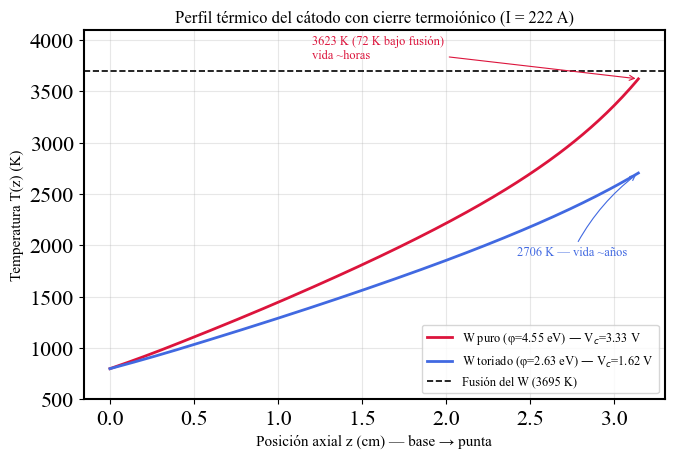

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(op_puro['z']*100, op_puro['T'], '-', color='crimson', lw=2,
        label=f"W puro (φ=4.55 eV) — V$_c$={op_puro['Vc']:.2f} V")
ax.plot(op_toriado['z']*100, op_toriado['T'], '-', color='royalblue', lw=2,
        label=f"W toriado (φ=2.63 eV) — V$_c$={op_toriado['Vc']:.2f} V")
ax.axhline(3695, color='k', ls='--', lw=1.2, label='Fusión del W (3695 K)')
ax.set_ylim(500, 4100)                       # ← aire sobre la línea de fusión

ax.annotate(f"{op_puro['T'][-1]:.0f} K (72 K bajo fusión)\nvida ~horas",
            xy=(op_puro['z'][-1]*100, op_puro['T'][-1]),
            xytext=(1.2, 3820), fontsize=9, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=0.8))
ax.annotate(f"{op_toriado['T'][-1]:.0f} K — vida ~años",
            xy=(op_toriado['z'][-1]*100, op_toriado['T'][-1]),
            xytext=(2.75, 1900), fontsize=9, color='royalblue',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='royalblue', lw=0.8,
                            connectionstyle='arc3,rad=-0.12'))

ax.set_xlabel('Posición axial z (cm) — base → punta', fontsize=11)
ax.set_ylabel('Temperatura T(z) (K)', fontsize=11)
ax.set_title('Perfil térmico del cátodo con cierre termoiónico (I = 222 A)', fontsize=12)
ax.legend(fontsize=9, loc='lower right')     # ← abajo, donde hay espacio vacío
ax.grid(alpha=0.3)
plt.savefig('perfil_termico_catodo.png', dpi=200, bbox_inches='tight')
plt.show()

## Flujo de calor sobre el barril del cátodo

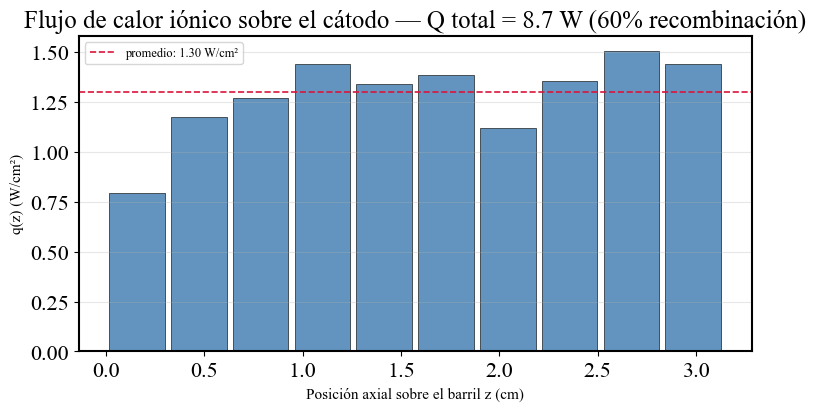

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 4), constrained_layout=True)
zc = 0.5*(FC['bins'][:-1] + FC['bins'][1:])*100
ax.bar(zc, FC['q_z'], width=(FC['bins'][1]-FC['bins'][0])*100*0.9,
       color='steelblue', alpha=0.85, edgecolor='k', lw=0.5)
ax.axhline(FC['Q_tot']/(2*np.pi*r_c*L_c*1e4), color='crimson', ls='--', lw=1.2,
           label=f"promedio: {FC['Q_tot']/(2*np.pi*r_c*L_c*1e4):.2f} W/cm²")
ax.set_xlabel('Posición axial sobre el barril z (cm)', fontsize=11)
ax.set_ylabel('q(z) (W/cm²)', fontsize=11)
ax.set_title(f"Flujo de calor iónico sobre el cátodo — Q total = {FC['Q_tot']:.1f} W "
             f"({100*FC['Q_rec']/FC['Q_tot']:.0f}% recombinación)")
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
plt.savefig('q_z_barril.png', dpi=200, bbox_inches='tight')
plt.show()

## Comparación de las tres topologías de campo

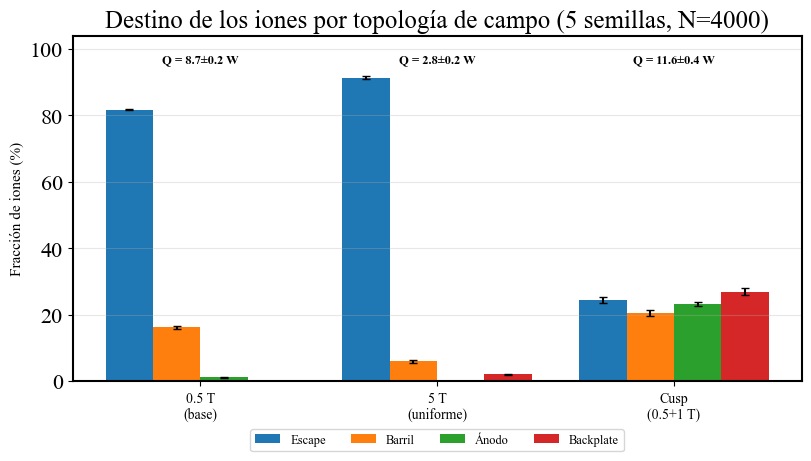

In [25]:
configs = ['0.5 T\n(base)', '5 T\n(uniforme)', 'Cusp\n(0.5+1 T)']
datos = {   # medias y desviaciones del RESULTADOS_v1
    'Escape':    ([81.77, 91.43, 24.44], [0.21, 0.48, 0.86]),
    'Barril':    ([16.24,  5.96, 20.54], [0.37, 0.48, 0.79]),
    'Ánodo':     ([ 1.27,  0.04, 23.24], [0.16, 0.03, 0.49]),
    'Backplate': ([ 0.00,  2.05, 26.97], [0.01, 0.24, 1.00]),
}
x = np.arange(3); ancho = 0.2
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
for i, (k, (m, s)) in enumerate(datos.items()):
    ax.bar(x + (i-1.5)*ancho, m, ancho, yerr=s, capsize=3, label=k)
for xi, q, sq in zip(x, [8.69, 2.78, 11.64], [0.20, 0.24, 0.39]):
    ax.text(xi, 96, f"Q = {q:.1f}±{sq:.1f} W", ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Fracción de iones (%)', fontsize=11)
ax.set_ylim(0, 104)
ax.set_title('Destino de los iones por topología de campo (5 semillas, N=4000)')
ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=10)
ax.legend(fontsize=9, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.grid(alpha=0.3, axis='y')
plt.savefig('topologias_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

# 22 · Barrido de intensidad de campo

Recorre el campo de tobera con repeticiones por punto y grafica el resultado con
barras de error.

B0 = 0.00 T: escape 67.56±0.42  barril 15.62±0.36  punta  0.18±0.05  anodo 16.16±0.25  backplate  0.00±0.00  
B0 = 0.10 T: escape 72.28±0.69  barril 15.92±0.48  punta  0.18±0.06  anodo 11.14±0.45  backplate  0.00±0.00  
B0 = 0.25 T: escape 77.76±0.62  barril 17.32±0.63  punta  0.18±0.07  anodo  4.26±0.31  backplate  0.00±0.00  
B0 = 0.50 T: escape 81.77±0.21  barril 16.24±0.37  punta  0.26±0.10  anodo  1.27±0.16  backplate  0.00±0.00  
B0 = 1.00 T: escape 85.00±0.49  barril 13.86±0.51  punta  0.18±0.07  anodo  0.44±0.09  backplate  0.04±0.01  
B0 = 2.00 T: escape 88.46±0.33  barril 10.46±0.29  punta  0.13±0.05  anodo  0.18±0.07  backplate  0.29±0.08  
B0 = 5.00 T: escape 91.43±0.48  barril  5.96±0.48  punta  0.05±0.05  anodo  0.04±0.03  backplate  2.05±0.24  


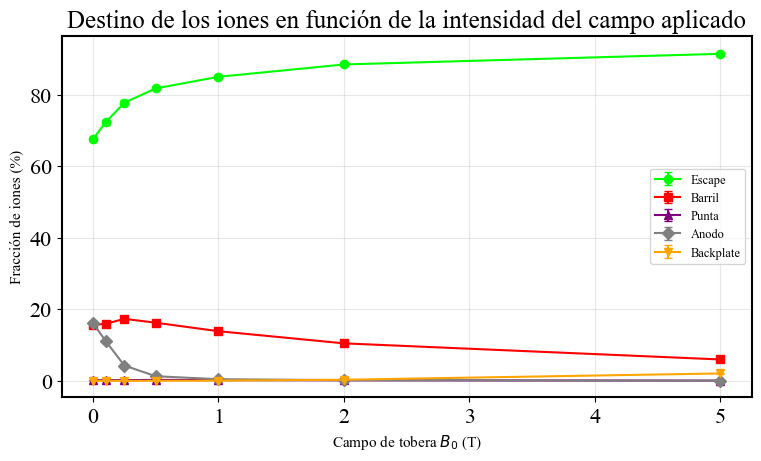

In [26]:
# --- Barrido de B0 con semillas + figura con barras de error ---
import numpy as np, matplotlib.pyplot as plt

valores_B0 = [0.0, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00]
claves = ['escape','barril','punta','anodo','backplate']
med, des = {k: [] for k in claves}, {k: [] for k in claves}

for B in valores_B0:
    runs = [simular_hts(B, N=4000, seed=s) for s in range(1, 6)]
    print(f"B0 = {B:.2f} T:", end=' ')
    for k in claves:
        a = np.array([r[k] for r in runs])
        med[k].append(a.mean()); des[k].append(a.std(ddof=1))
        print(f"{k} {a.mean():5.2f}±{a.std(ddof=1):.2f}", end='  ')
    print()

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
estilos = {'escape':('o-','lime'), 'barril':('s-','red'), 'punta':('^-','purple'),
           'anodo':('D-','gray'), 'backplate':('v-','orange')}
for k in claves:
    m, s = estilos[k]
    ax.errorbar(valores_B0, med[k], yerr=des[k], fmt=m, color=s, capsize=3, label=k.capitalize())
ax.set_xlabel('Campo de tobera $B_0$ (T)', fontsize=11)
ax.set_ylabel('Fracción de iones (%)', fontsize=11)
ax.set_title('Destino de los iones en función de la intensidad del campo aplicado')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.savefig('barrido_B0.png', dpi=200, bbox_inches='tight')
plt.show()